## Dataset Import and Model Train/Test

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# LOAD CLEANED DATA FROM DRIVE
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/chitwan_randomforest.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
leakage_cols = [
    'RISK_LEVEL', 'CONFLICT_TYPE', 'LOSS_INCURRED',
    'HUMAN_LOSS', 'LIVESTOCK_LOSS', 'PROPERTY_LOSS',
    'LOSS_OF_STORED GRAIN', 'CROP_RAIDED', 'TOTAL (NRS)'
]
X = df.drop(columns=leakage_cols)
y = df['RISK_LEVEL']

In [ ]:
# Map target labels to numbers (Ordinal: Low=0, Medium=1, High=2)
risk_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
y = y.map(risk_mapping)

In [ ]:
# Group rare animals into 'OTHER' so the model focuses on strong patterns
top_4 = ['TIGER', 'ELEPHANT', 'LEOPARD', 'RHINO']
df['PROBLEM_ANIMAL'] = df['PROBLEM_ANIMAL'].str.strip().str.upper()
df['PROBLEM_ANIMAL'] = df['PROBLEM_ANIMAL'].apply(lambda x: x if x in top_4 else 'OTHER')

# This ensures the dummies are clean and matchs pattern analysis

In [ ]:
# One-Hot Encode categorical features (BZUC and PROBLEM_ANIMAL)
X = pd.get_dummies(X, columns=['PROBLEM_ANIMAL', 'BZUC'])

In [ ]:
# TRAIN/TEST SPLIT
# Stratify=y ensures the 80/20 split maintains the same risk level proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Random Forest Classification

In [ ]:
# INITIALIZE & TRAIN RANDOM FOREST
# Using specific hyperparameter tuning
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced', # Handles the class imbalance (fewer High Risk cases)
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, random_state=42)

In [ ]:
# EVALUATION
y_pred = rf_model.predict(X_test)

In [ ]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=risk_mapping.keys()))

--- Classification Report ---
              precision    recall  f1-score   support

         LOW       0.75      0.93      0.83        99
      MEDIUM       0.95      0.89      0.92       251
        HIGH       0.86      0.78      0.82        72

    accuracy                           0.88       422
   macro avg       0.85      0.87      0.86       422
weighted avg       0.89      0.88      0.88       422



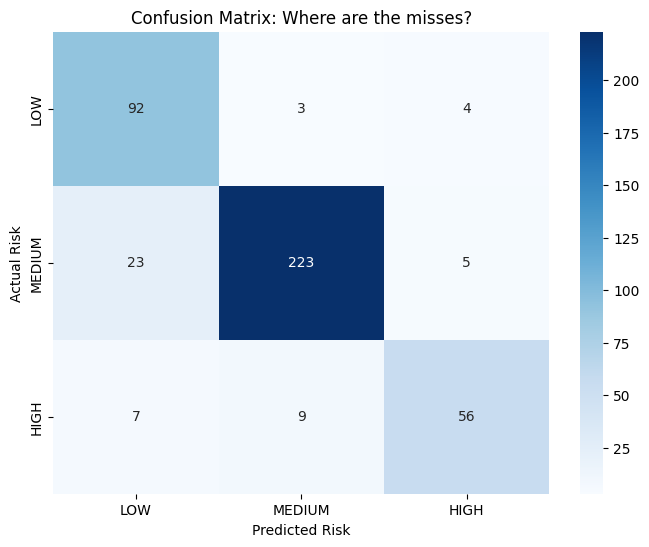

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=risk_mapping.keys(),
            yticklabels=risk_mapping.keys())
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.title('Confusion Matrix: Where are the misses?')
plt.show()



In [ ]:
# Safety Adjustment: Probability Thresholding
# Instead of just taking the highest probability, we can "tilt" the model
# to be more cautious about HIGH risk.
y_probs = rf_model.predict_proba(X_test)

# Lowering the "barrier" for HIGH risk (Class 2) from 0.5 to 0.3
custom_preds = []
for prob in y_probs:
    if prob[2] > 0.3: # If there's even a 30% chance of HIGH risk, flag it as HIGH
        custom_preds.append(2)
    else:
        custom_preds.append(np.argmax(prob))

print("\n--- Safety-Adjusted Classification Report ---")
print(classification_report(y_test, custom_preds, target_names=risk_mapping.keys()))


--- Safety-Adjusted Classification Report ---
              precision    recall  f1-score   support

         LOW       0.79      0.90      0.84        99
      MEDIUM       0.97      0.81      0.88       251
        HIGH       0.65      0.89      0.75        72

    accuracy                           0.84       422
   macro avg       0.80      0.87      0.82       422
weighted avg       0.87      0.84      0.85       422



### Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
# We use 'f1_macro' because of your class imbalance
scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1_macro')

print(f"Cross-Validation F1-Scores: {scores}")
print(f"Mean F1-Score: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Cross-Validation F1-Scores: [0.56499046 0.66652428 0.65993205 0.79946203 0.70093027]
Mean F1-Score: 0.68 (+/- 0.15)


In [ ]:
#hyperparameter tuning to impove the results

from sklearn.model_selection import GridSearchCV

# Define the parameters we want to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Initialize the Grid Search
# We use scoring='f1_macro' to stay focused on the "High Risk" safety class
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3, # 3-fold is faster for tuning
    scoring='f1_macro',
    n_jobs=-1 # Uses all CPU cores
)

# Run the search
print("Searching for the best settings... this may take a minute.")
grid_search.fit(X_train, y_train)

# Results
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Evaluate the "Optimized" Model
y_pred_best = best_rf.predict(X_test)
print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=risk_mapping.keys()))

Searching for the best settings... this may take a minute.
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

--- Optimized Classification Report ---
              precision    recall  f1-score   support

         LOW       0.82      0.90      0.86        99
      MEDIUM       0.93      0.93      0.93       251
        HIGH       0.87      0.75      0.81        72

    accuracy                           0.89       422
   macro avg       0.87      0.86      0.87       422
weighted avg       0.89      0.89      0.89       422



In [ ]:
#Final Cross-Validation
from sklearn.model_selection import cross_val_score

# Run CV on the best estimator found by the Grid Search
optimized_scores = cross_val_score(best_rf, X, y, cv=5, scoring='f1_macro')

print(f"Optimized CV F1-Scores: {optimized_scores}")
print(f"Optimized Mean F1-Score: {optimized_scores.mean():.2f} (+/- {optimized_scores.std() * 2:.2f})")

Optimized CV F1-Scores: [0.55892414 0.63606286 0.57918392 0.8110815  0.71042932]
Optimized Mean F1-Score: 0.66 (+/- 0.18)


In [ ]:
from sklearn.metrics import cohen_kappa_score

# Calculate Kappa for your optimized model
kappa = cohen_kappa_score(y_test, y_pred_best)

print(f"Cohen's Kappa Coefficient: {kappa:.3f}")

Cohen's Kappa Coefficient: 0.809


## Hotspot Identification Grid Visualization

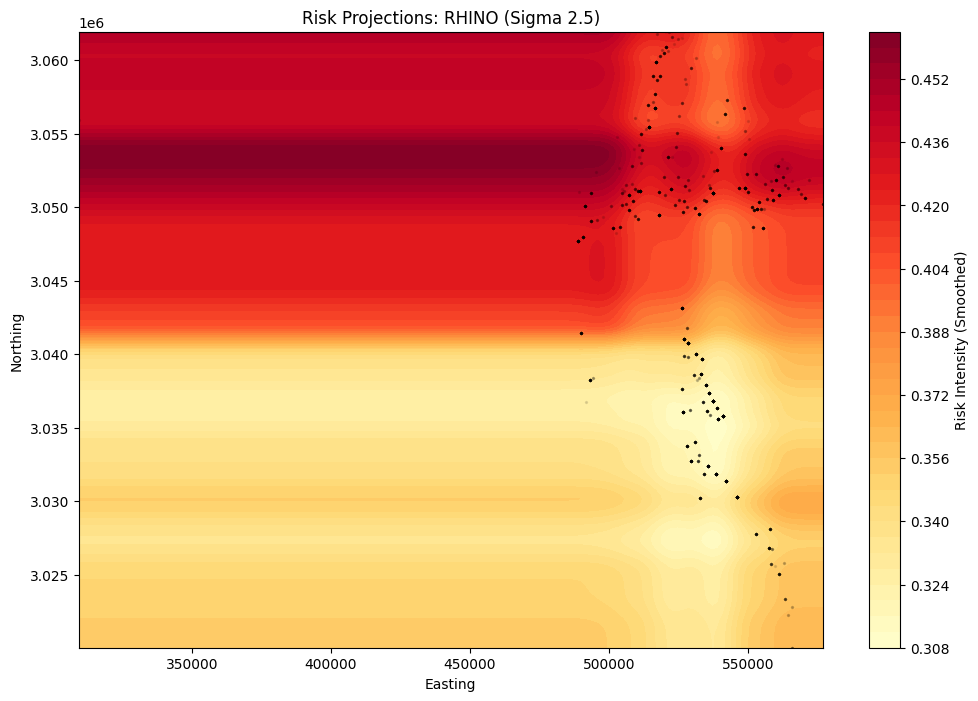

In [ ]:
from scipy.ndimage import gaussian_filter

def generate_circular_hotspots(target_month, target_animal, target_lunar=15, sigma=2.0):
    # 1. Define boundaries
    x_min, x_max = df['Easting'].min(), df['Easting'].max()
    y_min, y_max = df['Northing'].min(), df['Northing'].max()

    # 2. Create the grid (higher number = smoother)
    grid_res = 150
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                                 np.linspace(y_min, y_max, grid_res))

    # 3. Prepare data for model
    flat_x = grid_x.flatten()
    flat_y = grid_y.flatten()
    grid_df = pd.DataFrame(0, index=np.arange(len(flat_x)), columns=X.columns)
    grid_df['Easting'] = flat_x
    grid_df['Northing'] = flat_y
    grid_df['Month'] = target_month
    grid_df['LUNAR_DAY'] = target_lunar
    grid_df['Population'] = df['Population'].mean()
    grid_df['BZUC_Area_ha'] = df['BZUC_Area_ha'].mean()

    animal_col = f'PROBLEM_ANIMAL_{target_animal}'
    if animal_col in grid_df.columns:
        grid_df[animal_col] = 1

    # 4. Predict High Risk Probability (Class 2)
    # Ensure you use your best model variable name (rf_model or best_rf)
    probs = rf_model.predict_proba(grid_df)[:, 2]
    grid_probs = probs.reshape(grid_x.shape)

    # 5. Apply Gaussian Smoothing
    # sigma=1 is sharp, sigma=3 is very soft/circular
    smooth_probs = gaussian_filter(grid_probs, sigma=sigma)

    # 6. Plot
    plt.figure(figsize=(12, 8))
    # Use 'contourf' for a professional "Heatmap" look
    plt.contourf(grid_x, grid_y, smooth_probs, levels=50, cmap='YlOrRd')
    plt.colorbar(label='Risk Intensity (Smoothed)')

    # Plot historical incidents as context
    plt.scatter(df['Easting'], df['Northing'], c='black', s=2, alpha=0.1, label='Historical incidents')

    plt.title(f'Risk Projections: {target_animal} (Sigma {sigma})')
    plt.xlabel('Easting')
    plt.ylabel('Northing')
    plt.show()

# Run it!
generate_circular_hotspots(target_month=10, target_animal='RHINO', target_lunar=1, sigma=2.5)

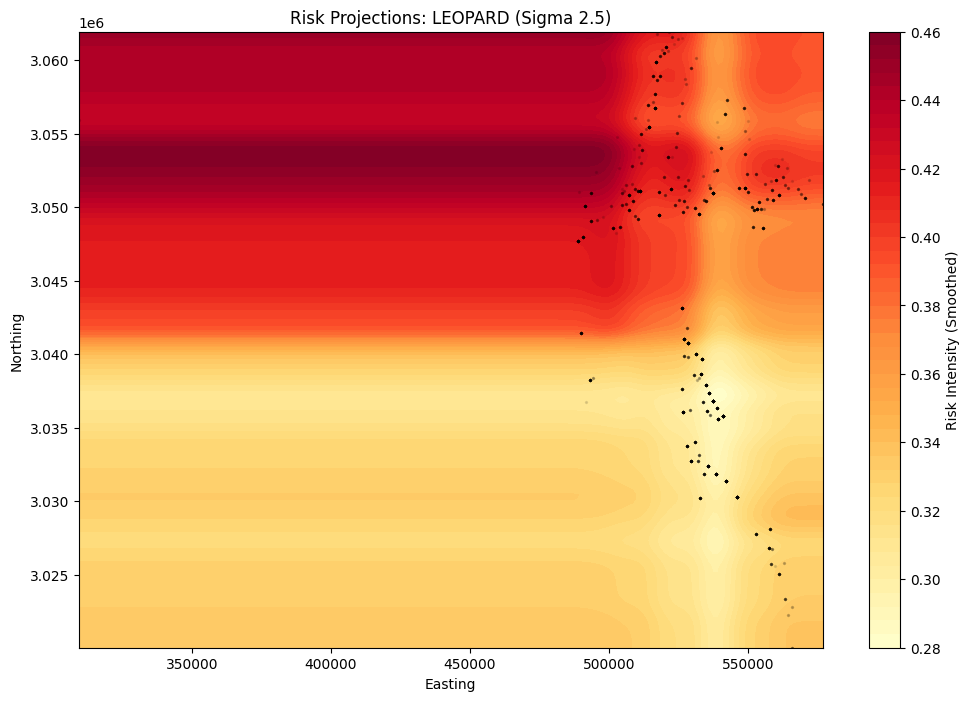

In [ ]:
# Generate the hotspot map for LEOPARD
generate_circular_hotspots(target_month=10, target_animal='LEOPARD', sigma=2.5)

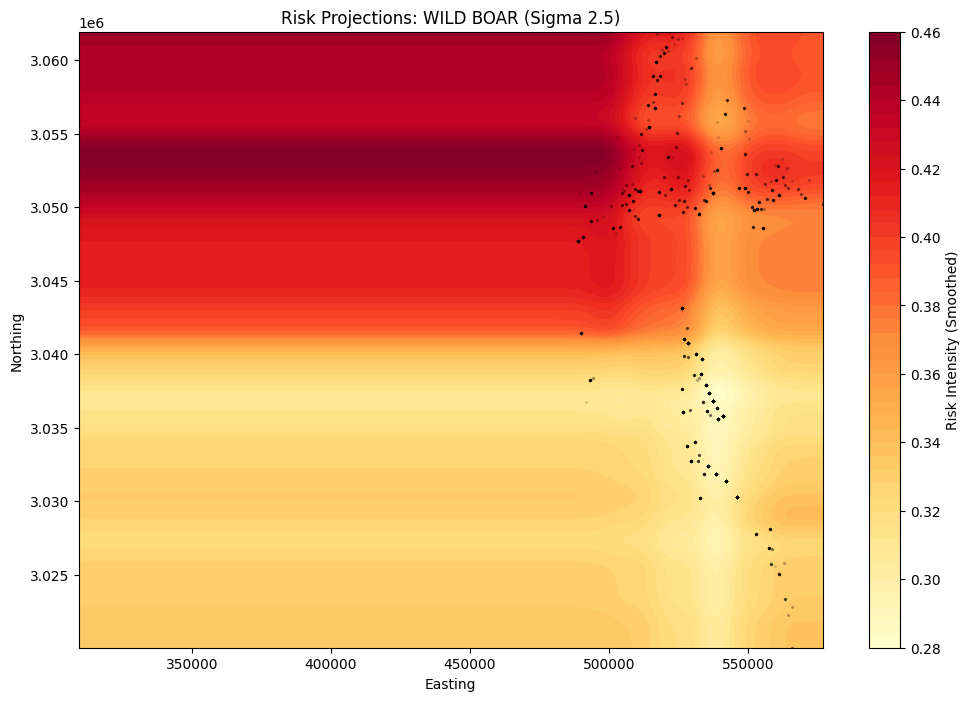

In [ ]:
# Generate the hotspot map for WILD BOAR
generate_circular_hotspots(target_month=10, target_animal='WILD BOAR', sigma=2.5)

/tmp/ipykernel_151/3176565422.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')


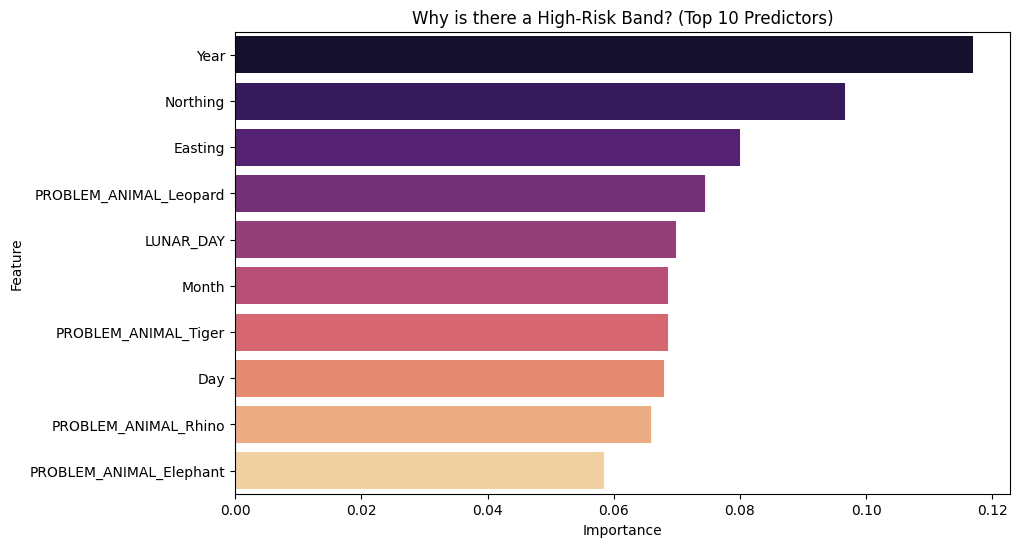

In [ ]:
# Get feature importance from your model
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')
plt.title('Why is there a High-Risk Band? (Top 10 Predictors)')
plt.show()

In [ ]:
import joblib

# 1. Save the trained model
joblib.dump(rf_model, 'chitwan_rf_model.pkl')

# 2. Save the feature names (CRITICAL: for backend to know the exact column order)
model_features = list(X.columns)
joblib.dump(model_features, 'model_features.pkl')

print("Model and Feature List exported for System Integration!")

Model and Feature List exported for System Integration!


In [ ]:
import shutil

# Saving to drive
shutil.move('chitwan_rf_model.pkl', '/content/drive/MyDrive/chitwan_rf_model.pkl')

shutil.move('model_features.pkl', '/content/drive/MyDrive/model_features.pkl')

print("Files safely moved to your Google Drive!")

Files safely moved to your Google Drive!
